# HR Employee Attrition Analysis
This project aims to identify key factors influencing employee attrition using data analysis and visualization. We'll explore the data to find insights to support HR decision-making.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset
file = pd. read_csv("HR-Employee-Attrition.csv")
file.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview
Let's check the shape, column types, and information.

In [3]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Data Cleaning
Let's handle duplicates, irrelevant column types, and missing values.

In [4]:
print(file.duplicated().sum())
print(file.duplicated("EmployeeNumber").sum())

0
0


- We can see that there is no duplicates in this dataset

In [5]:
print("Overall Null Count: " ,file.isnull().sum().sum())

Overall Null Count:  0


- We can see that there is no null values in this dataset

## Exploratory Data Analysis
We'll analyse and visualize attrition patterns across different features.

01. Calculate the overall attrition percentage in the company.
02. Identify the top 3 job roles with the highest attrition rates.
03. Does marital status have any relation to attrition?
04. Compare attrition between employees who travel frequently vs. rarely.
05. Analyze attrition trends across different age groups (e.g., <30, 30–40, >40).
06. Find the average monthly income of employees who left compared to those who stayed.
07. Check if distance from home significantly influences attrition.
08. Study attrition by education field – which education field has the highest rate?
09. Compare attrition among different job levels.
10. Is there a significant difference in attrition between males and females?
11. How does overtime impact employee attrition?
12. Find the relationship between work-life balance rating and attrition.
13. Do employees with fewer years at the company tend to leave more often?
14. Compare attrition rates for employees with different performance ratings.
15. Find whether employees with higher job satisfaction stay longer.
16. Analyze if training opportunities (YearsSinceLastPromotion) influence attrition.
17. Study the correlation between monthly income and years at the company.
18. Identify outliers in employee income and check if they impact attrition.
19. What is the average age, income, and years at the company of employees who left vs. those who stayed?
20. Which departments have the highest attrition?
21. Create a histogram of employee ages – what is the most common age range of employees?
22. Build a simple attrition risk profile: list top 5 factors strongly linked to attrition.
23. Suggest HR strategies (based on analysis) that could help reduce attrition.

#### 01. Calculate the overall attrition percentage in the company.

In [6]:
attrition_count = file.groupby(['Attrition'])['EmployeeNumber'].count()

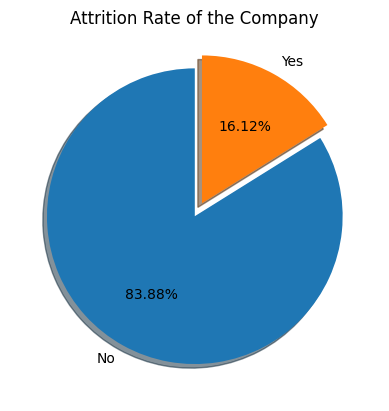

In [7]:
plt.pie(attrition_count.values,labels=attrition_count.index,
        autopct='%1.2f%%',
        explode=(0,0.1), 
        shadow=True,
        startangle=90)
plt.title("Attrition Rate of the Company")
plt.show()

- attrition percentage = (Number of employess left / Average number of employees (or) Total number of employees) * 100
- Number of employess left = 237
- Total number of employees = 1470
- Attrition Rate = 16.12%

#### 02. Identify the top 3 job roles with the highest attrition rates.

In [8]:
attrition_count_jobrole = file.pivot_table(index='JobRole', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_jobrole_sorted = attrition_count_jobrole['Yes'].sort_values()

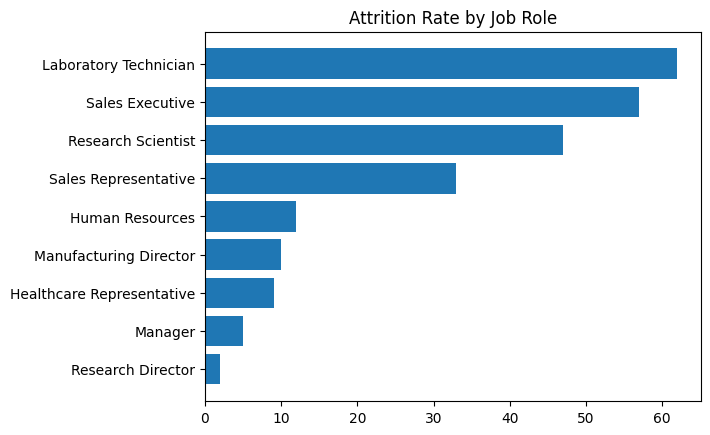

In [9]:
plt.barh(attrition_count_jobrole_sorted.index,attrition_count_jobrole_sorted.values)
plt.title("Attrition Rate by Job Role")
plt.show()

- Top 3 Job Roles with high attrition rates
  1.  Laboratory Technician - 62
  2.  Sales Executive - 57
  3.  Research Scientist - 47

#### 03. Does marital status have any relation to attrition?

In [10]:
attrition_maritalstatus = file.pivot_table(index='MaritalStatus', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_maritalstatus_yes = attrition_maritalstatus['Yes']

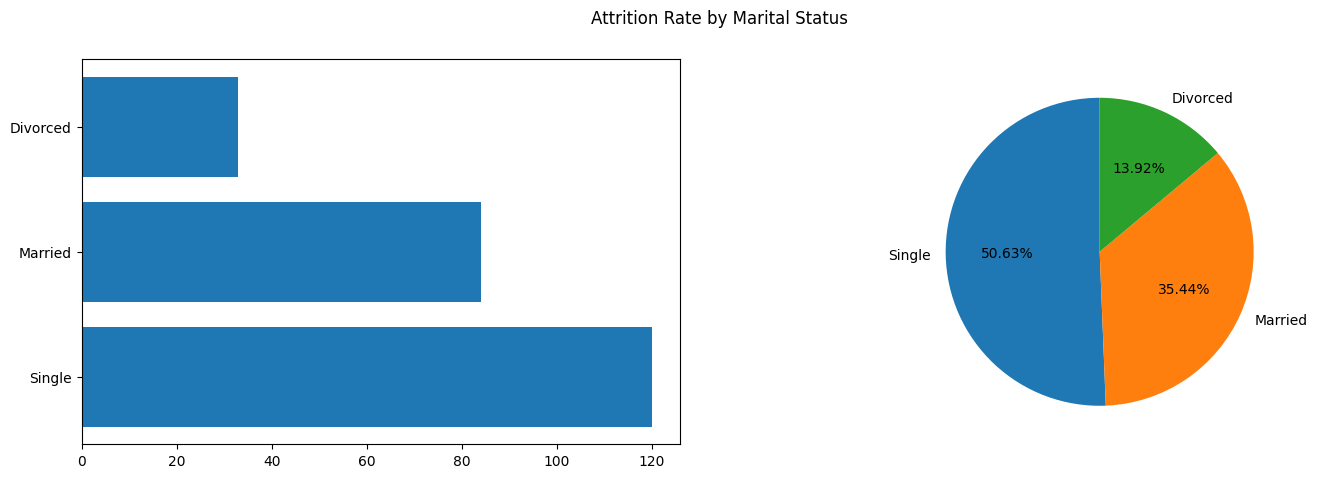

In [11]:
plt.figure(figsize=(17,5))
plt.suptitle("Attrition Rate by Marital Status")

plt.subplot(1,2,1)
plt.barh(attrition_maritalstatus_yes.index,attrition_maritalstatus_yes.values)

plt.subplot(1,2,2)
plt.pie(attrition_maritalstatus_yes.values,labels=attrition_maritalstatus_yes.index,
        autopct='%1.2f%%', 
        startangle=90)
plt.show()

- Unmarried singles are most likely to left the company comparitively than married and divorced

#### 4. Compare attrition between employees who travel frequently vs. rarely

In [12]:
attrition_BusinessTravel = file.pivot_table(index='BusinessTravel', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_BusinessTravel_yes = attrition_BusinessTravel['Yes']

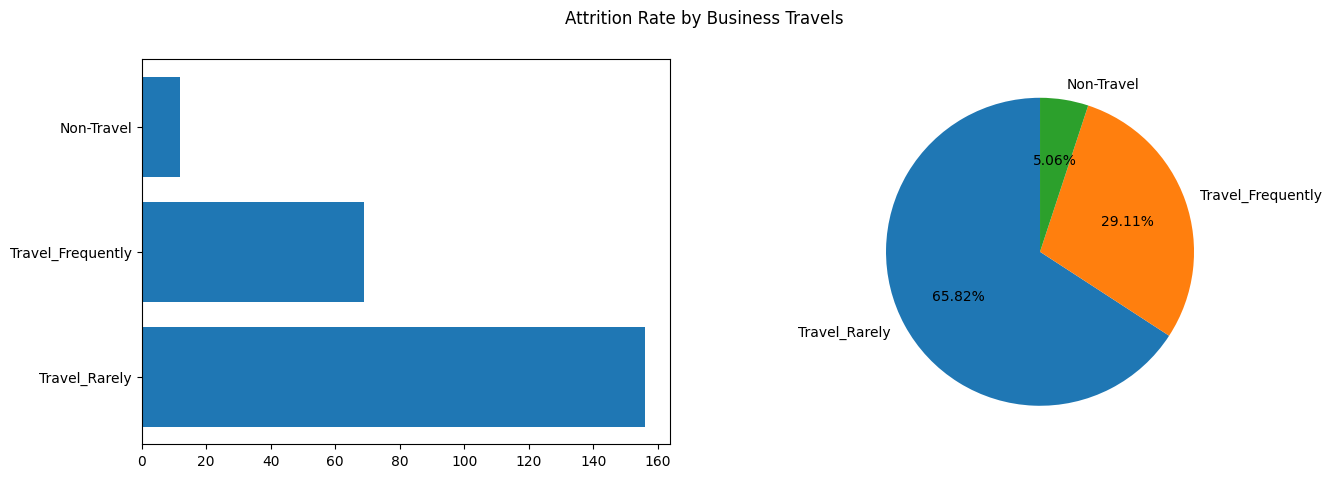

In [13]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition Rate by Business Travels")

plt.subplot(1,2,1)
plt.barh(attrition_BusinessTravel_yes.index,attrition_BusinessTravel_yes.values)

plt.subplot(1,2,2)
plt.pie(attrition_BusinessTravel_yes.values,labels=attrition_BusinessTravel_yes.index,
        autopct='%1.2f%%', 
        startangle=90)
plt.show()

- In this analysis we are supposed to know that, people who <strong>travel rarely are most likely to left the company</strong>.

#### 5. Analyze attrition trends across different age groups (e.g., <30, 30–40, >40)

In [14]:
file['AgeGroup'] = pd.cut(file['Age'], bins=[0,30,40,100],labels=['Below 30','30 to 40','Above 40'] )

In [15]:
attrition_age = file.pivot_table(index='AgeGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = False, observed=True )

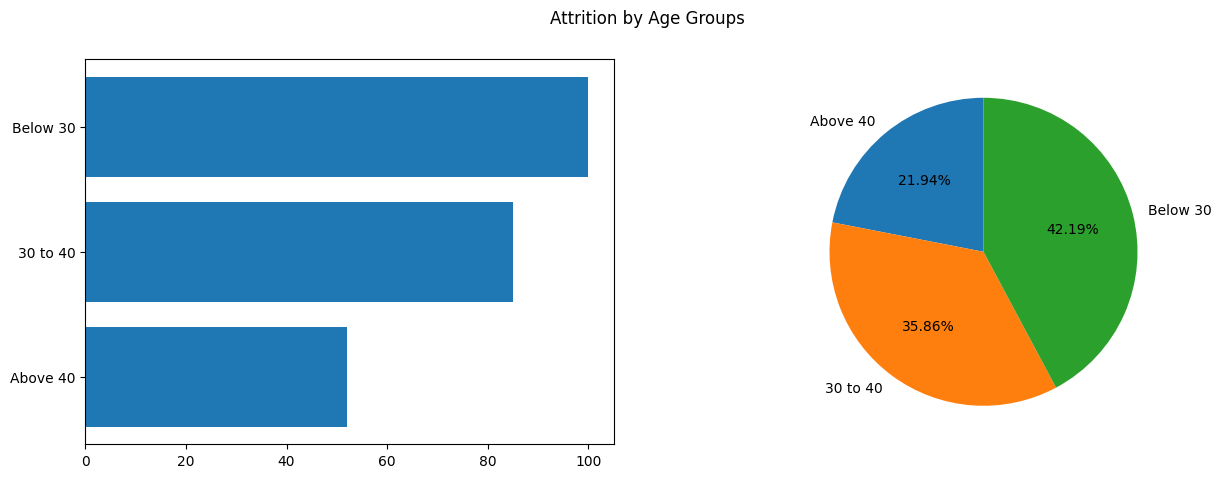

In [16]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition by Age Groups")


plt.subplot(1,2,1)
plt.barh(attrition_age.index,attrition_age['Yes'])

plt.subplot(1,2,2)
plt.pie(attrition_age['Yes'],labels=attrition_age.index,
        autopct='%1.2f%%', 
        startangle=90)
plt.show()

- In this analysis, We can see that people below 30 are left the company most

#### 6. Find the average monthly income of employees who left compared to those who stayed

In [17]:
attrition_monthlyincome = file.groupby(['Attrition'])['MonthlyIncome'].mean()

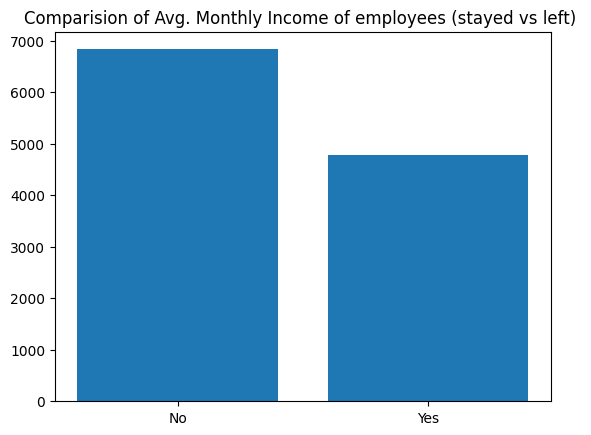

In [18]:
plt.bar(attrition_monthlyincome.index,attrition_monthlyincome.values)
plt.title("Comparision of Avg. Monthly Income of employees (stayed vs left) ")
plt.show()

- The avg Monthly income of current employees is greater than the employees who left the company
    - The avg Monthly income of current employees – 6832.73
    - The avg Monthly income of left employees – 4787.09

#### 7. Check if distance from home significantly influences attrition

In [19]:
attrition_DistanceFromHome = file.pivot_table(index='DistanceFromHome', columns='Attrition',aggfunc='size',fill_value=0, sort = True )

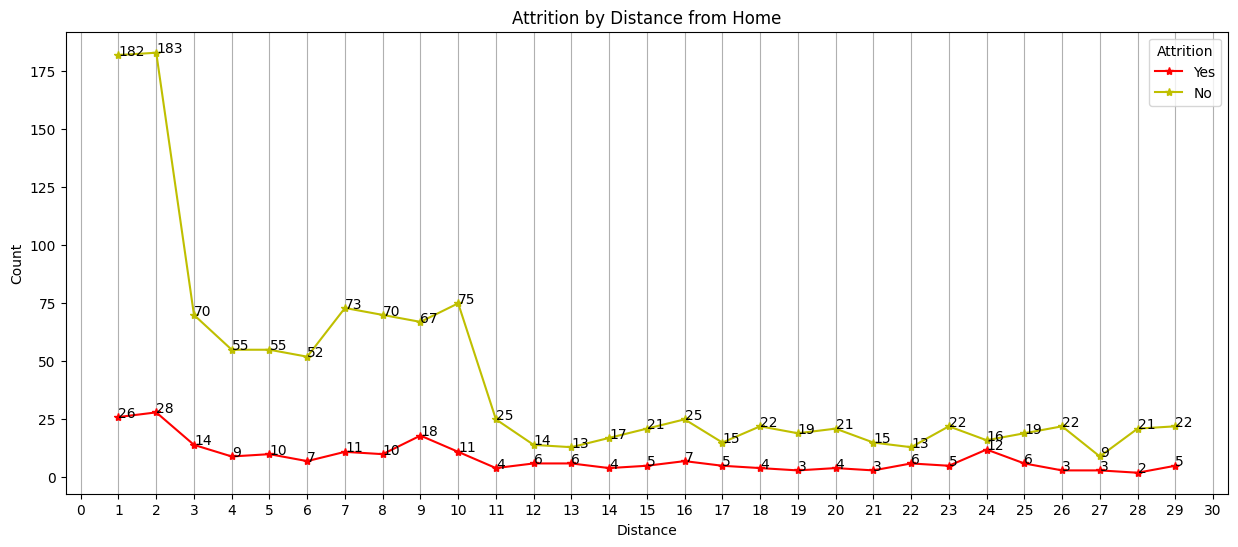

In [20]:
plt.figure(figsize=(15,6))
plt.plot(attrition_DistanceFromHome.index,attrition_DistanceFromHome['Yes'],color='r',marker="*",label='Yes')
plt.plot(attrition_DistanceFromHome.index,attrition_DistanceFromHome['No'],color='y',marker="*",label='No')
plt.title("Attrition by Distance from Home")
for x,y,z in zip(attrition_DistanceFromHome.index,attrition_DistanceFromHome['Yes'],attrition_DistanceFromHome['No']):
    plt.annotate(y,xy=(x,y))
    plt.annotate(z,xy=(x,z))
plt.xlabel("Distance")
plt.ylabel("Count")
plt.xticks(list(x for x in range(31)))
plt.grid(axis='x')
plt.legend(title="Attrition")
plt.show()

- We can see that, no relation is affected the attrition rate by distance from home
- The no. of employees having small distance(1-10) is greater than no. of employees having medium distance(10-20) and long distance(20-30)

#### 8. Study attrition by education field – which education field has the highest rate?

In [21]:
attrition_count_EducationField = file.pivot_table(index='EducationField', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_EducationField_sorted = attrition_count_EducationField['Yes'].sort_values()

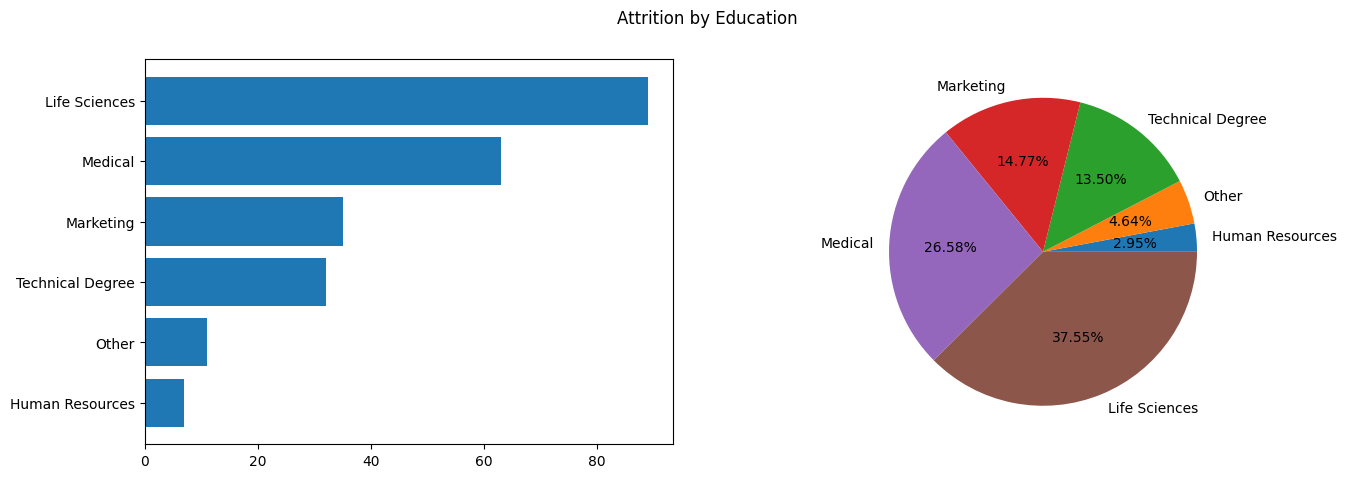

In [22]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition by Education")

plt.subplot(1,2,1)
plt.barh(attrition_count_EducationField_sorted.index,attrition_count_EducationField_sorted.values)

plt.subplot(1,2,2)
plt.pie(attrition_count_EducationField_sorted.values,labels=attrition_count_EducationField_sorted.index,autopct="%1.2f%%")
plt.show()

- Life science is the education field having the highest rate of attrition(37.55%)

#### 9. Compare attrition among different job levels.

In [23]:
attrition_count_JobLevel = file.pivot_table(index='JobLevel', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_JobLevel_sorted = attrition_count_JobLevel['Yes'].sort_values()

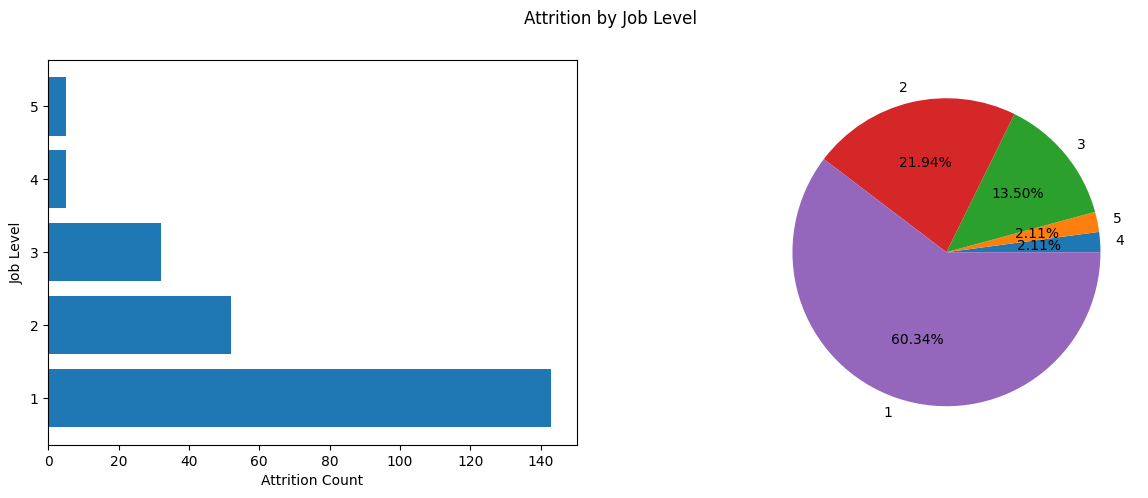

In [24]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition by Job Level")

plt.subplot(1,2,1)
plt.barh(attrition_count_JobLevel_sorted.index,attrition_count_JobLevel_sorted.values)
plt.ylabel('Job Level')
plt.xlabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_JobLevel_sorted.values,
        labels=attrition_count_JobLevel_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- The employees in Level 1 job is most likely to left the job

#### 10. Is there a significant difference in attrition between males and females?

In [25]:
attrition_count_Gender = file.pivot_table(index='Gender', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_Gender_sorted = attrition_count_Gender['Yes'].sort_values()

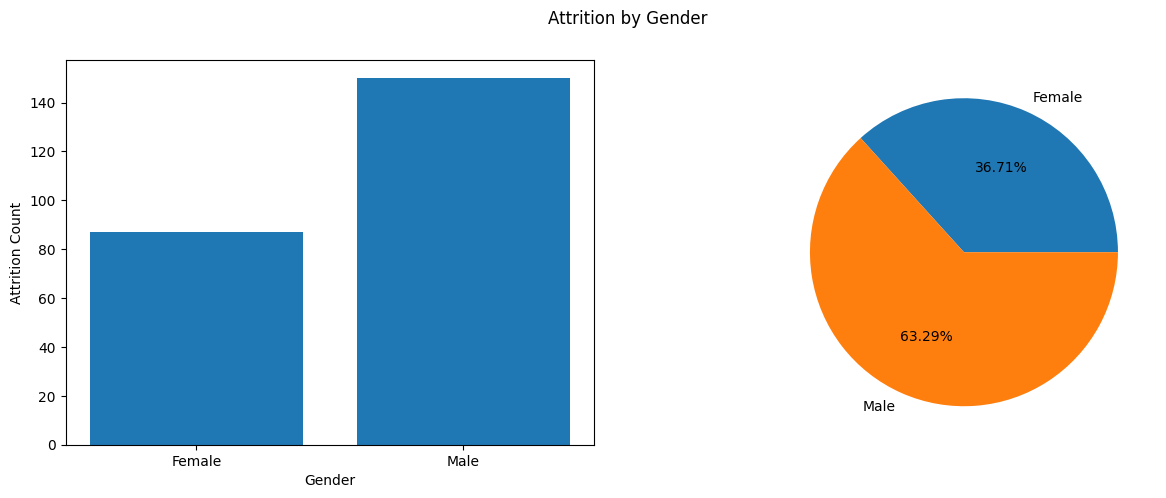

In [26]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition by Gender")

plt.subplot(1,2,1)
plt.bar(attrition_count_Gender_sorted.index,attrition_count_Gender_sorted.values)
plt.xlabel('Gender')
plt.ylabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_Gender_sorted.values,
        labels=attrition_count_Gender_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- Yes, there a significant difference in attrition between males and females.
- Male employees(63.3%) are left the company most, compared to female employees(36.7%)

#### 11. How does overtime impact employee attrition?

In [27]:
attrition_count_OverTime = file.pivot_table(index='OverTime', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_OverTime_sorted = attrition_count_OverTime['Yes'].sort_values()

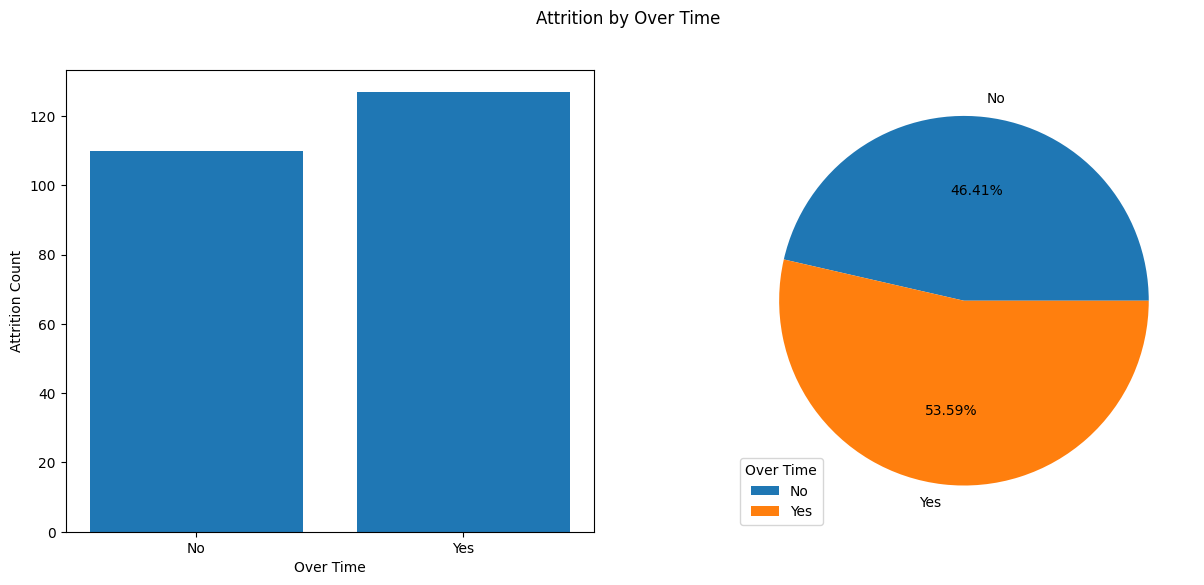

In [28]:
plt.figure(figsize=(15,6))
plt.suptitle("Attrition by Over Time")

plt.subplot(1,2,1)
plt.bar(attrition_count_OverTime_sorted.index,attrition_count_OverTime_sorted.values)
plt.xlabel('Over Time')
plt.ylabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_OverTime_sorted.values,
        labels=attrition_count_OverTime_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.legend(title=("Over Time"),loc='lower left')
plt.show()

- The Over time is not a major factor of attrition, but also the employees who work overtime were left the company than those who don't

#### 12. Find the relationship between work-life balance rating and attrition

In [29]:
attrition_count_WorkLifeBalance = file.pivot_table(index='WorkLifeBalance', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_WorkLifeBalance_sorted = attrition_count_WorkLifeBalance['Yes'].sort_values()

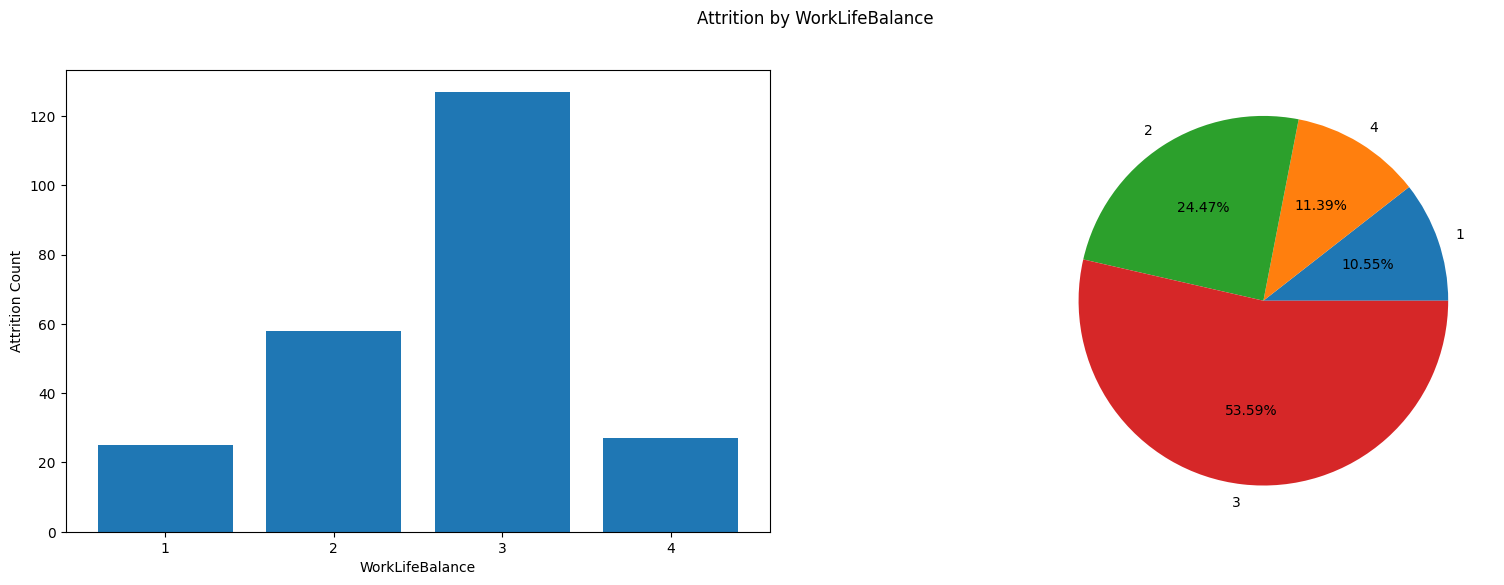

In [30]:
plt.figure(figsize=(20,6))
plt.suptitle("Attrition by WorkLifeBalance")

plt.subplot(1,2,1)
plt.bar(attrition_count_WorkLifeBalance_sorted.index,attrition_count_WorkLifeBalance_sorted.values)
plt.xlabel('WorkLifeBalance')
plt.xticks([1,2,3,4])
plt.ylabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_WorkLifeBalance_sorted.values,
        labels=attrition_count_WorkLifeBalance_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- The employees who have a work life balance at 3rd level had left the company most by 53.59%

#### 13. Do employees with fewer years at the company tend to leave more often?

In [31]:
file['YearsAtCompanyGroup'] = pd.cut(file['YearsAtCompany'], 
                                     bins=[-1,5,10,15,20,25,30,35,40,45],
                                     labels=['0-5','5-10','10-15','10-20','20-25','25-30','30-35','35-40','40-45'])


In [32]:
attrition_count_YearsAtCompany = file.pivot_table(index='YearsAtCompanyGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = True, observed=True)
attrition_count_YearsAtCompany_sorted = attrition_count_YearsAtCompany['Yes'].sort_index()

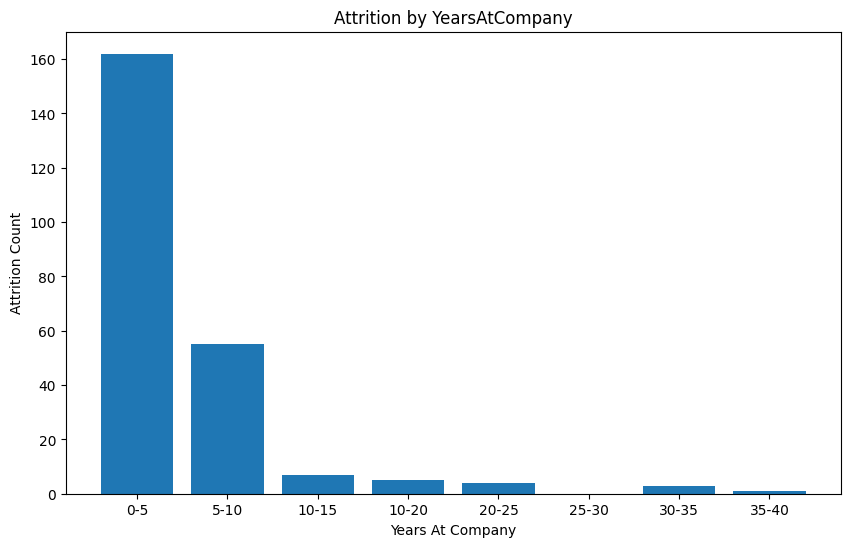

In [33]:
plt.figure(figsize=(10,6))
plt.title("Attrition by YearsAtCompany")
plt.bar(attrition_count_YearsAtCompany_sorted.index,attrition_count_YearsAtCompany_sorted.values)
plt.xlabel('Years At Company')
plt.ylabel("Attrition Count")
plt.show()

- Yes, the employees with fewer years(0-5) at the company tend to leave more often

#### 14. Compare attrition rates for employees with different performance ratings.

In [34]:
attrition_count_PerformanceRating = file.pivot_table(index='PerformanceRating', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_PerformanceRating_sorted = attrition_count_PerformanceRating['Yes'].sort_values()

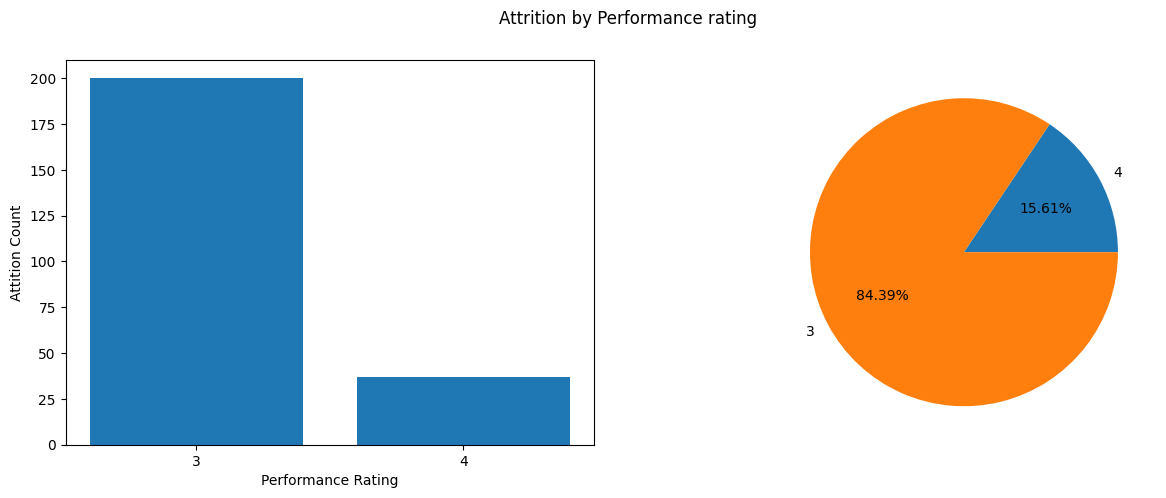

In [35]:
plt.figure(figsize=(15,5))
plt.suptitle("Attrition by Performance rating")

plt.subplot(1,2,1)
plt.bar(attrition_count_PerformanceRating_sorted.index, attrition_count_PerformanceRating_sorted.values)
plt.xlabel("Performance Rating")
plt.xticks([3,4])
plt.ylabel("Attition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_PerformanceRating_sorted.values,
        labels=attrition_count_PerformanceRating_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- Here the employees with the performance rating of 3 had left the company most(84.39%)

#### 15. Find whether employees with higher job satisfaction stay longer.

In [36]:
attrition_count_JobSatisfaction = file.pivot_table(index='JobSatisfaction', columns='Attrition',aggfunc='size',fill_value=0, sort = False )
attrition_count_JobSatisfaction_sorted = attrition_count_JobSatisfaction['Yes'].sort_index()

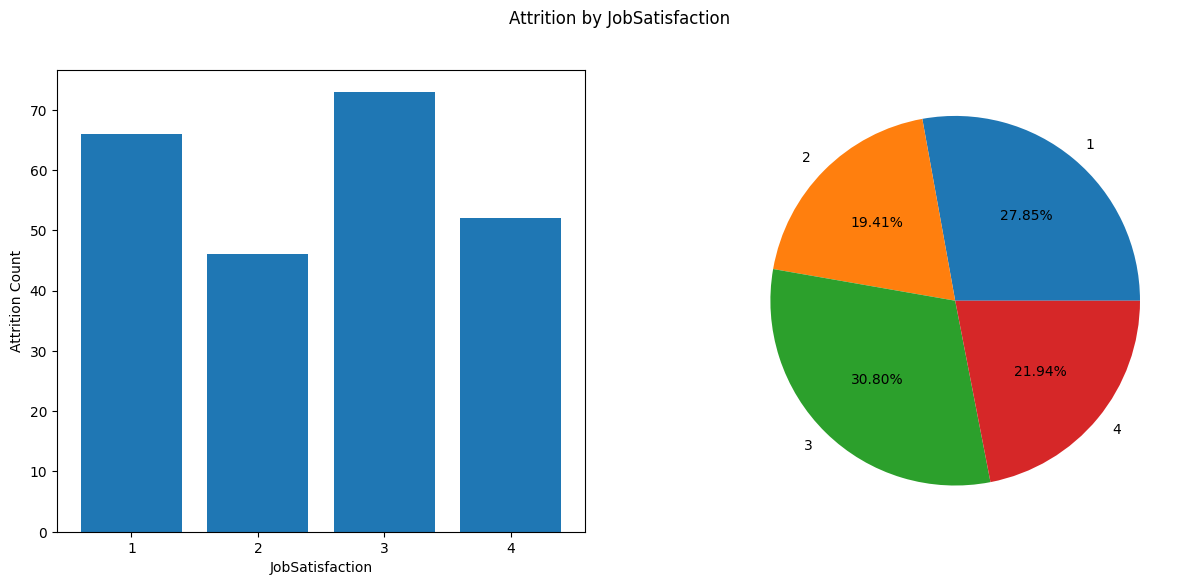

In [37]:
plt.figure(figsize=(15,6))
plt.suptitle("Attrition by JobSatisfaction")

plt.subplot(1,2,1)
plt.bar(attrition_count_JobSatisfaction_sorted.index,attrition_count_JobSatisfaction_sorted.values)
plt.xlabel('JobSatisfaction')
plt.xticks([1,2,3,4])
plt.ylabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_JobSatisfaction_sorted.values,
        labels=attrition_count_JobSatisfaction_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- Here we cant see any relation that affects the attrition rates
- The attrition rate is high for Job satisfaction level 1 and 3 

#### 16. Analyze if training opportunities (YearsSinceLastPromotion) influence attrition.

In [38]:
attrition_count_YearsSinceLastPromotion = file.pivot_table(index='YearsSinceLastPromotion', columns='Attrition',aggfunc='size',fill_value=0, sort = True )
attrition_count_YearsSinceLastPromotion_sorted = attrition_count_YearsSinceLastPromotion['Yes']
attrition_count_TrainingTimesLastYear = file.pivot_table(index='TrainingTimesLastYear', columns='Attrition',aggfunc='size',fill_value=0, sort = True )
attrition_count_TrainingTimesLastYear_sorted = attrition_count_TrainingTimesLastYear['Yes']

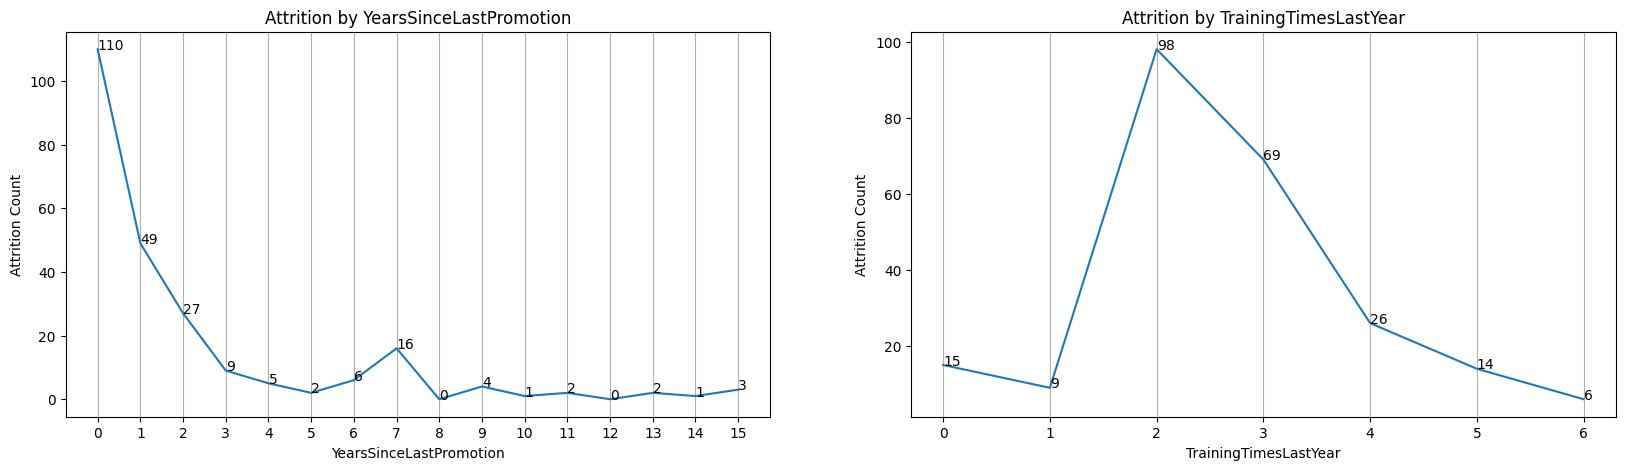

In [39]:
plt.figure(figsize=(20,5))

plt.subplot(1,2,1)
plt.plot(attrition_count_YearsSinceLastPromotion_sorted.index,attrition_count_YearsSinceLastPromotion_sorted.values)
plt.title("Attrition by YearsSinceLastPromotion")
plt.xlabel('YearsSinceLastPromotion')
plt.xticks(list(x for x in range(16)))
plt.ylabel("Attrition Count")
for x,y in zip(attrition_count_YearsSinceLastPromotion_sorted.index,attrition_count_YearsSinceLastPromotion_sorted.values):
    plt.annotate(y,xy=(x,y))
plt.grid(axis='x')

plt.subplot(1,2,2)
plt.title("Attrition by TrainingTimesLastYear")
plt.plot(attrition_count_TrainingTimesLastYear_sorted.index,attrition_count_TrainingTimesLastYear_sorted.values)
plt.xlabel('TrainingTimesLastYear')
plt.ylabel("Attrition Count")
for x,y in zip(attrition_count_TrainingTimesLastYear_sorted.index,attrition_count_TrainingTimesLastYear_sorted.values):
    plt.annotate(y,xy=(x,y))
plt.grid(axis='x')
plt.show()

- The people who got the promotion before 1 or 2 years had left the company mostly

#### 17. Study the correlation between monthly income and years at the company.

In [40]:
print(file['MonthlyIncome'].describe()) # checking min and max income

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


In [41]:
file['MonthlyIncomeGroup'] = pd.cut(file['MonthlyIncome'], 
                                     bins=[0,2000,4000,6000,8000,10000,12000,14000,16000,18000,20000,22000],
                                     labels=['0-2000','2000-4000','4000-6000','6000-8000','8000-10000','10000-12000',
                                             '12000-14000','14000-16000','16000-18000','18000-20000','20000-22000']) #creating new column to group the income levels

In [42]:
attrition_count_MonthlyIncome = file.pivot_table(index='MonthlyIncomeGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = True, observed=True)
attrition_count_MonthlyIncome_sorted = attrition_count_MonthlyIncome['Yes'].sort_index()
attrition_count_YearsAtCompany = file.pivot_table(index='YearsAtCompanyGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = True, observed=True)
attrition_count_YearsAtCompany_sorted = attrition_count_YearsAtCompany['Yes'].sort_index()

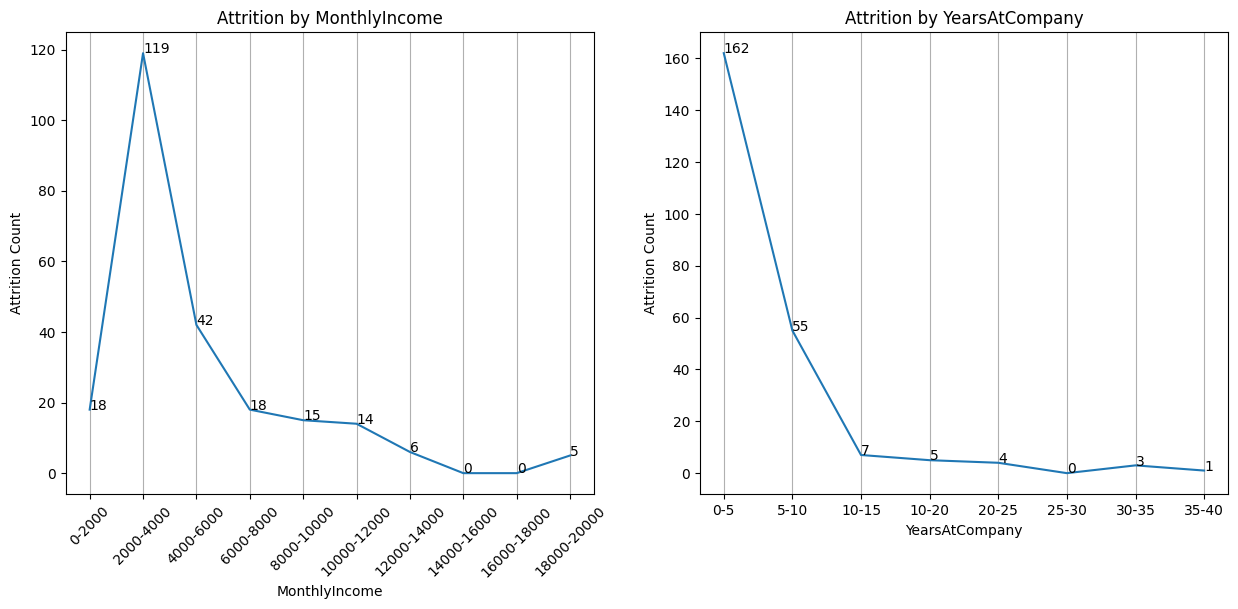

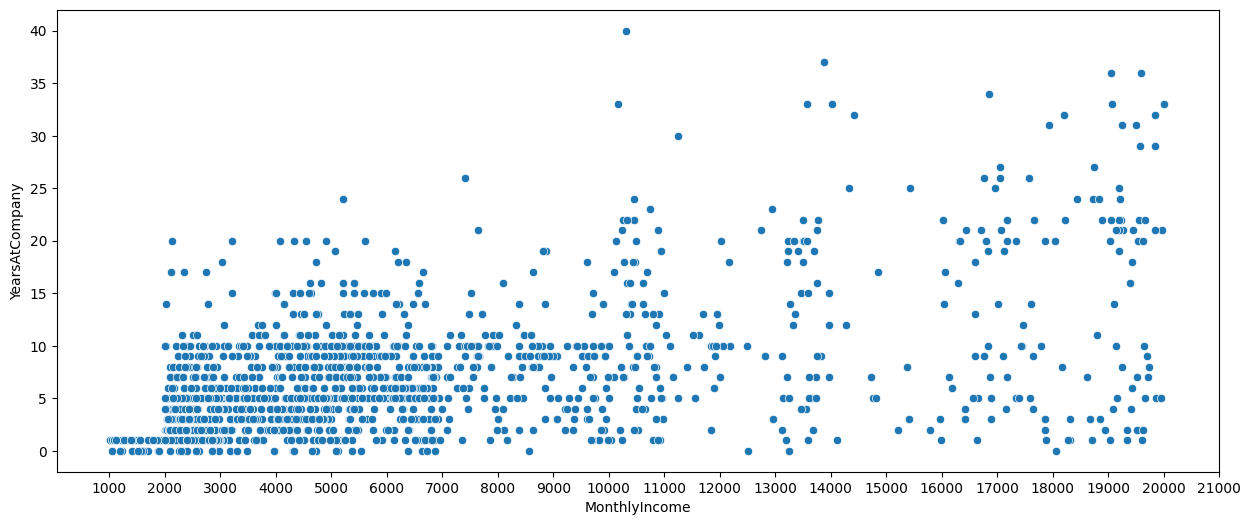

In [43]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.plot(attrition_count_MonthlyIncome_sorted.index,attrition_count_MonthlyIncome_sorted.values)
plt.title("Attrition by MonthlyIncome")
plt.xlabel('MonthlyIncome')
plt.xticks(rotation=45)
plt.ylabel("Attrition Count")
for x,y in zip(attrition_count_MonthlyIncome_sorted.index,attrition_count_MonthlyIncome_sorted.values):
    plt.annotate(y,xy=(x,y))
plt.grid(axis='x')

plt.subplot(1,2,2)
plt.title("Attrition by YearsAtCompany")
plt.plot(attrition_count_YearsAtCompany_sorted.index,attrition_count_YearsAtCompany_sorted.values)
plt.xlabel('YearsAtCompany')
plt.ylabel("Attrition Count")
for x,y in zip(attrition_count_YearsAtCompany_sorted.index,attrition_count_YearsAtCompany_sorted.values):
    plt.annotate(y,xy=(x,y))
plt.grid(axis='x')
plt.show()

plt.figure(figsize=(15,6))
sns.scatterplot(x='MonthlyIncome', y='YearsAtCompany', data=file)
plt.xticks(list(x for x in range(1000,22000,1000)))
plt.show()

- We can see that employees who have monthly income between 2000 to 8000 and who work at the company for 0 – 10 years were left the company most

#### 18. Identify outliers in employee income and check if they impact attrition.

In [44]:
df = file #copying the df to another one

In [45]:
#checking for outliers in duplicate dataset and removing it
outliers_count = 1
while (outliers_count > 0):

    i = 'MonthlyIncome'
    
    Q1 = df[i].quantile(0.25) #finding the first quartile
    Q3 = df[i].quantile(0.75) #finding the thirt quartile
    
    IQR = Q3 - Q1 #finding inter quartile range
    
    LB = Q1 - (1.5 * IQR) #finding the lower bound
    UB = Q3 + (1.5 * IQR) #finding the lower bound
    
    outliers = df[(df[i] < LB) | (df[i] > UB)] #checking for outliers
    outliers_count = outliers.count().sum()
    df.drop(outliers.index, inplace=True)

print(i)
print("Q1,Q3 = ",Q1,Q3)
print("IQR = ",IQR)
print("LB,UB = ",LB,UB)
print("outliers = \n",outliers_count)

MonthlyIncome
Q1,Q3 =  2757.5 6291.0
IQR =  3533.5
LB,UB =  -2542.75 11591.25
outliers = 
 0


<Axes: xlabel='MonthlyIncome'>

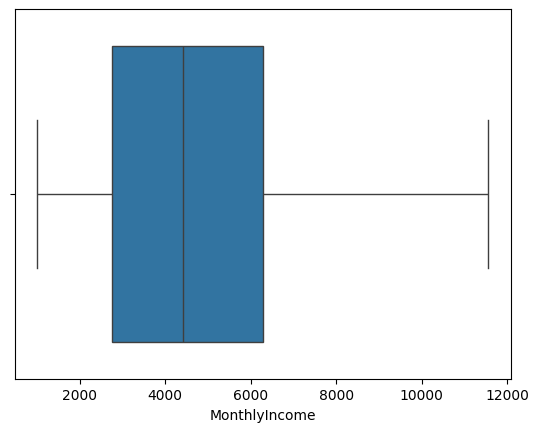

In [46]:
sns.boxplot(data=df,x='MonthlyIncome') #checking the outliers through box plot

In [47]:
df['MonthlyIncomeGroup'] = pd.cut(df['MonthlyIncome'], 
                                     bins=[0,2000,4000,6000,8000,10000,12000,14000,16000,18000,20000,22000],
                                     labels=['0-2000','2000-4000','4000-6000','6000-8000','8000-10000','10000-12000',
                                             '12000-14000','14000-16000','16000-18000','18000-20000','20000-22000']) #creating new column to group the income levels in duplicate dataset

In [48]:
df_attrition_count_MonthlyIncome = df.pivot_table(index='MonthlyIncomeGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = True, observed=True)
df_attrition_count_MonthlyIncome_sorted = df_attrition_count_MonthlyIncome['Yes'].sort_index()
df_attrition_count_MonthlyIncome_sorted

MonthlyIncomeGroup
0-2000          18
2000-4000      119
4000-6000       42
6000-8000       18
8000-10000      15
10000-12000     13
Name: Yes, dtype: int64

In [49]:
attrition_count_MonthlyIncome = file.pivot_table(index='MonthlyIncomeGroup', columns='Attrition',aggfunc='size',fill_value=0, sort = True, observed=True)
attrition_count_MonthlyIncome_sorted = attrition_count_MonthlyIncome['Yes'].sort_index()
attrition_count_MonthlyIncome_sorted

MonthlyIncomeGroup
0-2000          18
2000-4000      119
4000-6000       42
6000-8000       18
8000-10000      15
10000-12000     13
Name: Yes, dtype: int64

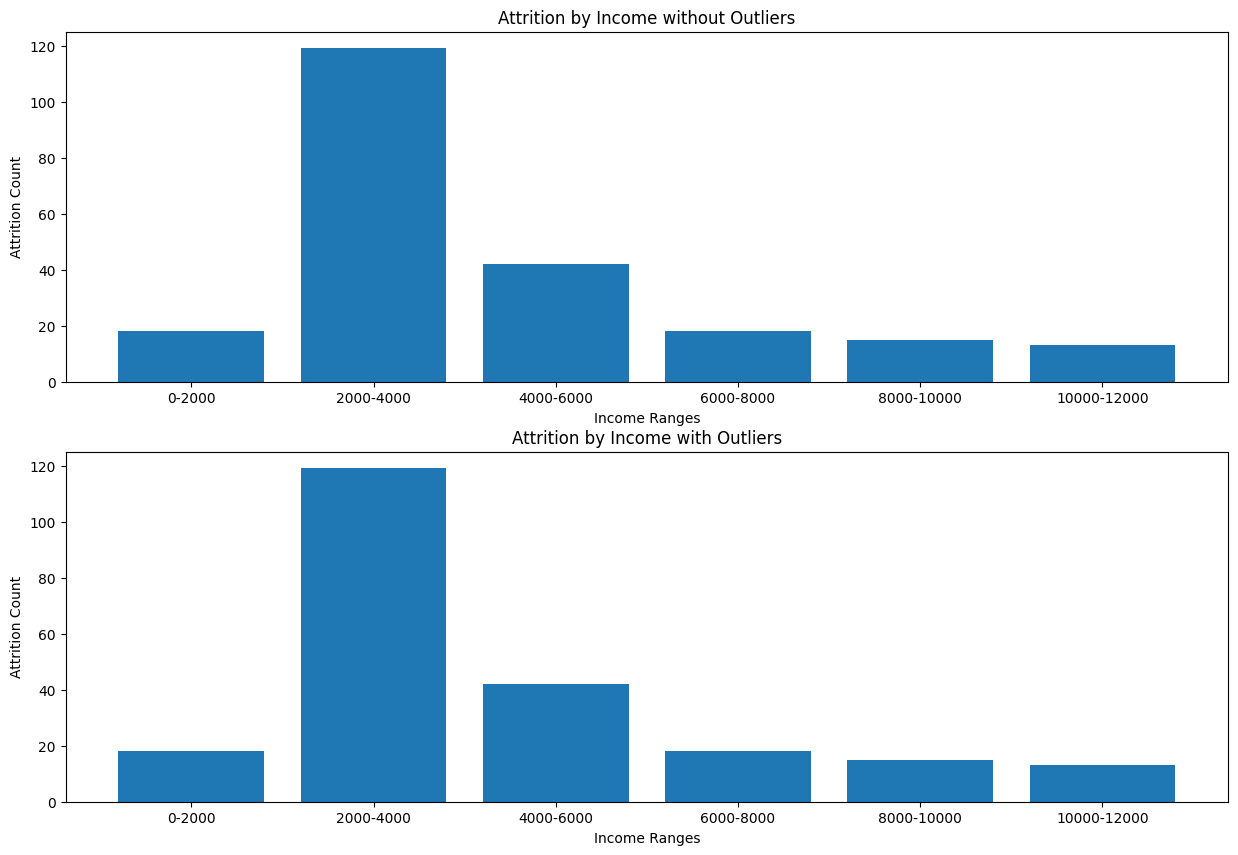

In [50]:
plt.figure(figsize=(15,10))

plt.subplot(2,1,1)
plt.bar(df_attrition_count_MonthlyIncome_sorted.index,df_attrition_count_MonthlyIncome_sorted.values)
plt.title("Attrition by Income without Outliers")
plt.xlabel("Income Ranges")
plt.ylabel("Attrition Count")

plt.subplot(2,1,2)
plt.bar(attrition_count_MonthlyIncome_sorted.index,attrition_count_MonthlyIncome_sorted.values)
plt.title("Attrition by Income with Outliers")
plt.xlabel("Income Ranges")
plt.ylabel("Attrition Count")
plt.show()

- We cannot see any huge difference in with and without outliers. Only 12 employee incomes were removed as outliers

#### 19. What is the average age, income, and years at the company of employees who left vs. those who stayed?

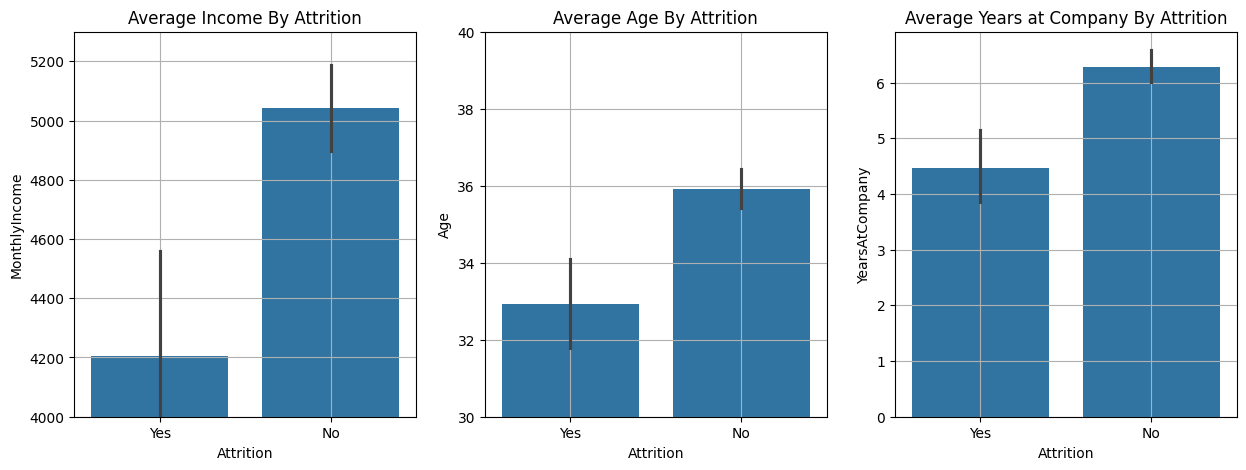

In [51]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.barplot(data=file,x='Attrition',y='MonthlyIncome')
plt.title("Average Income By Attrition")
plt.ylim(4000,5300)
plt.grid()

plt.subplot(1,3,2)
sns.barplot(data=file,x='Attrition',y='Age')
plt.title("Average Age By Attrition")
plt.ylim(30,40)
plt.grid()

plt.subplot(1,3,3)
sns.barplot(data=file,x='Attrition',y='YearsAtCompany')
plt.title("Average Years at Company By Attrition")
plt.grid()

- Avg. Income of the people who left the company is around $4200.
- Avg. Age of the people who left the company is around 33.
- Avg. Years working at this company of the people who left the company is around 4.5.

#### 20. Which departments have the highest attrition?

In [52]:
attrition_count_Department = file.pivot_table(index='Department', columns='Attrition',aggfunc='size',fill_value=0, sort = True )
attrition_count_Department_sorted = attrition_count_Department['Yes']

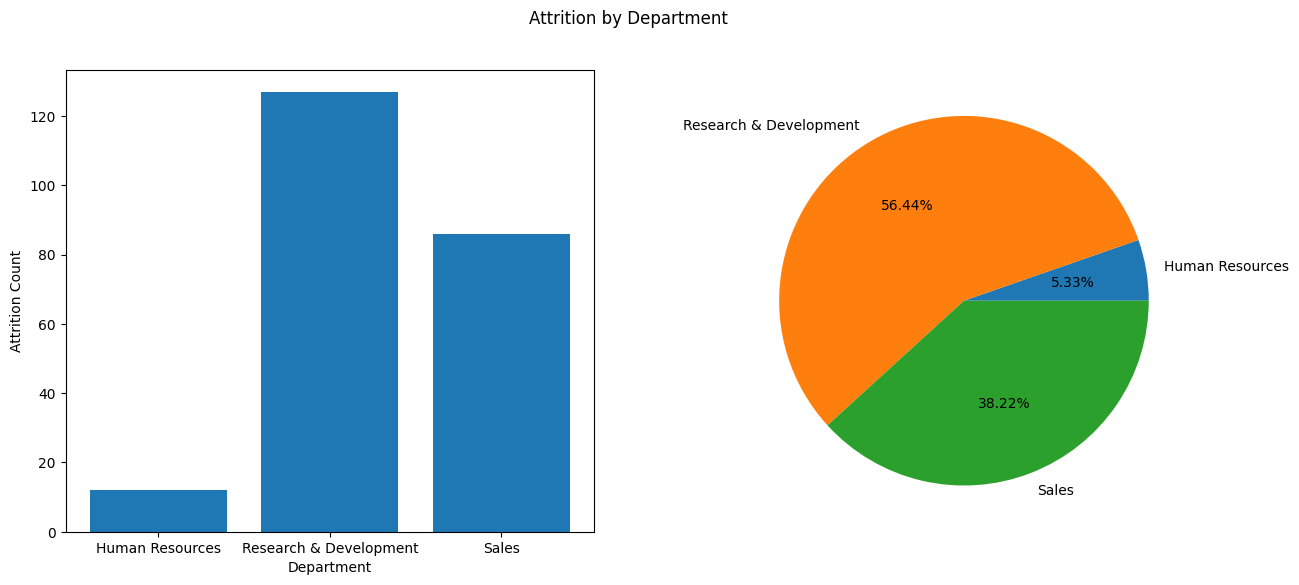

In [53]:
plt.figure(figsize=(15,6))
plt.suptitle("Attrition by Department")

plt.subplot(1,2,1)
plt.bar(attrition_count_Department_sorted.index,attrition_count_Department_sorted.values)
plt.xlabel('Department')
plt.ylabel("Attrition Count")

plt.subplot(1,2,2)
plt.pie(attrition_count_Department_sorted.values,
        labels=attrition_count_Department_sorted.index,
        autopct='%1.2f%%',
        startangle=0)
plt.show()

- R&D has the highest rate of attrition(56.44%) followed by Sales(38.22%) and HR(5.33%)

#### 21. Create a histogram of employee ages – what is the most common age range of employees?

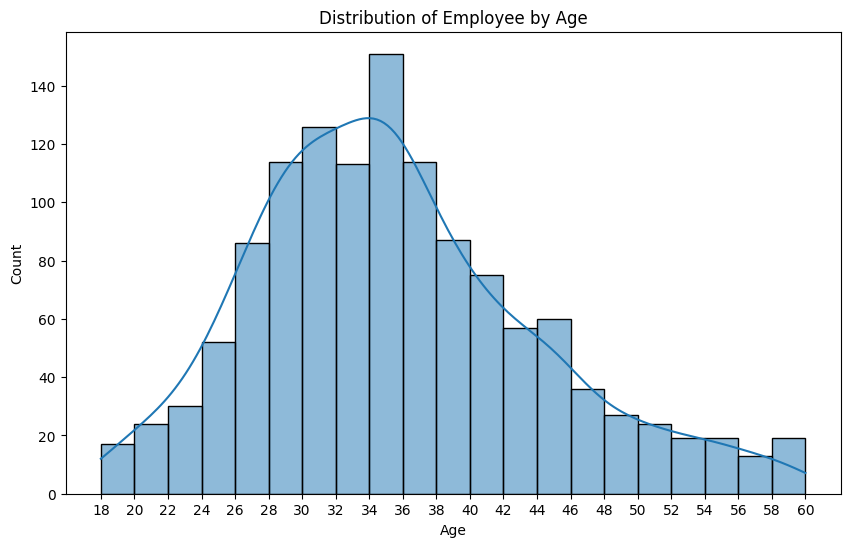

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(data=file, x='Age', kde=True,)
plt.title('Distribution of Employee by Age')
plt.xlabel('Age')
plt.xticks(list(x for x in range(18,61,2)))
plt.ylabel('Count')
plt.show()

- The most common ages of the employees lies between 30 - 40

#### 22. Build a simple attrition risk profile: list top 5 factors strongly linked to attrition

- These are top 5 factors that affect Attrition Rate
    1. Job Levels
    2. Years at the Company
    3. Marital Status
    4. Age
    5. Job Roles


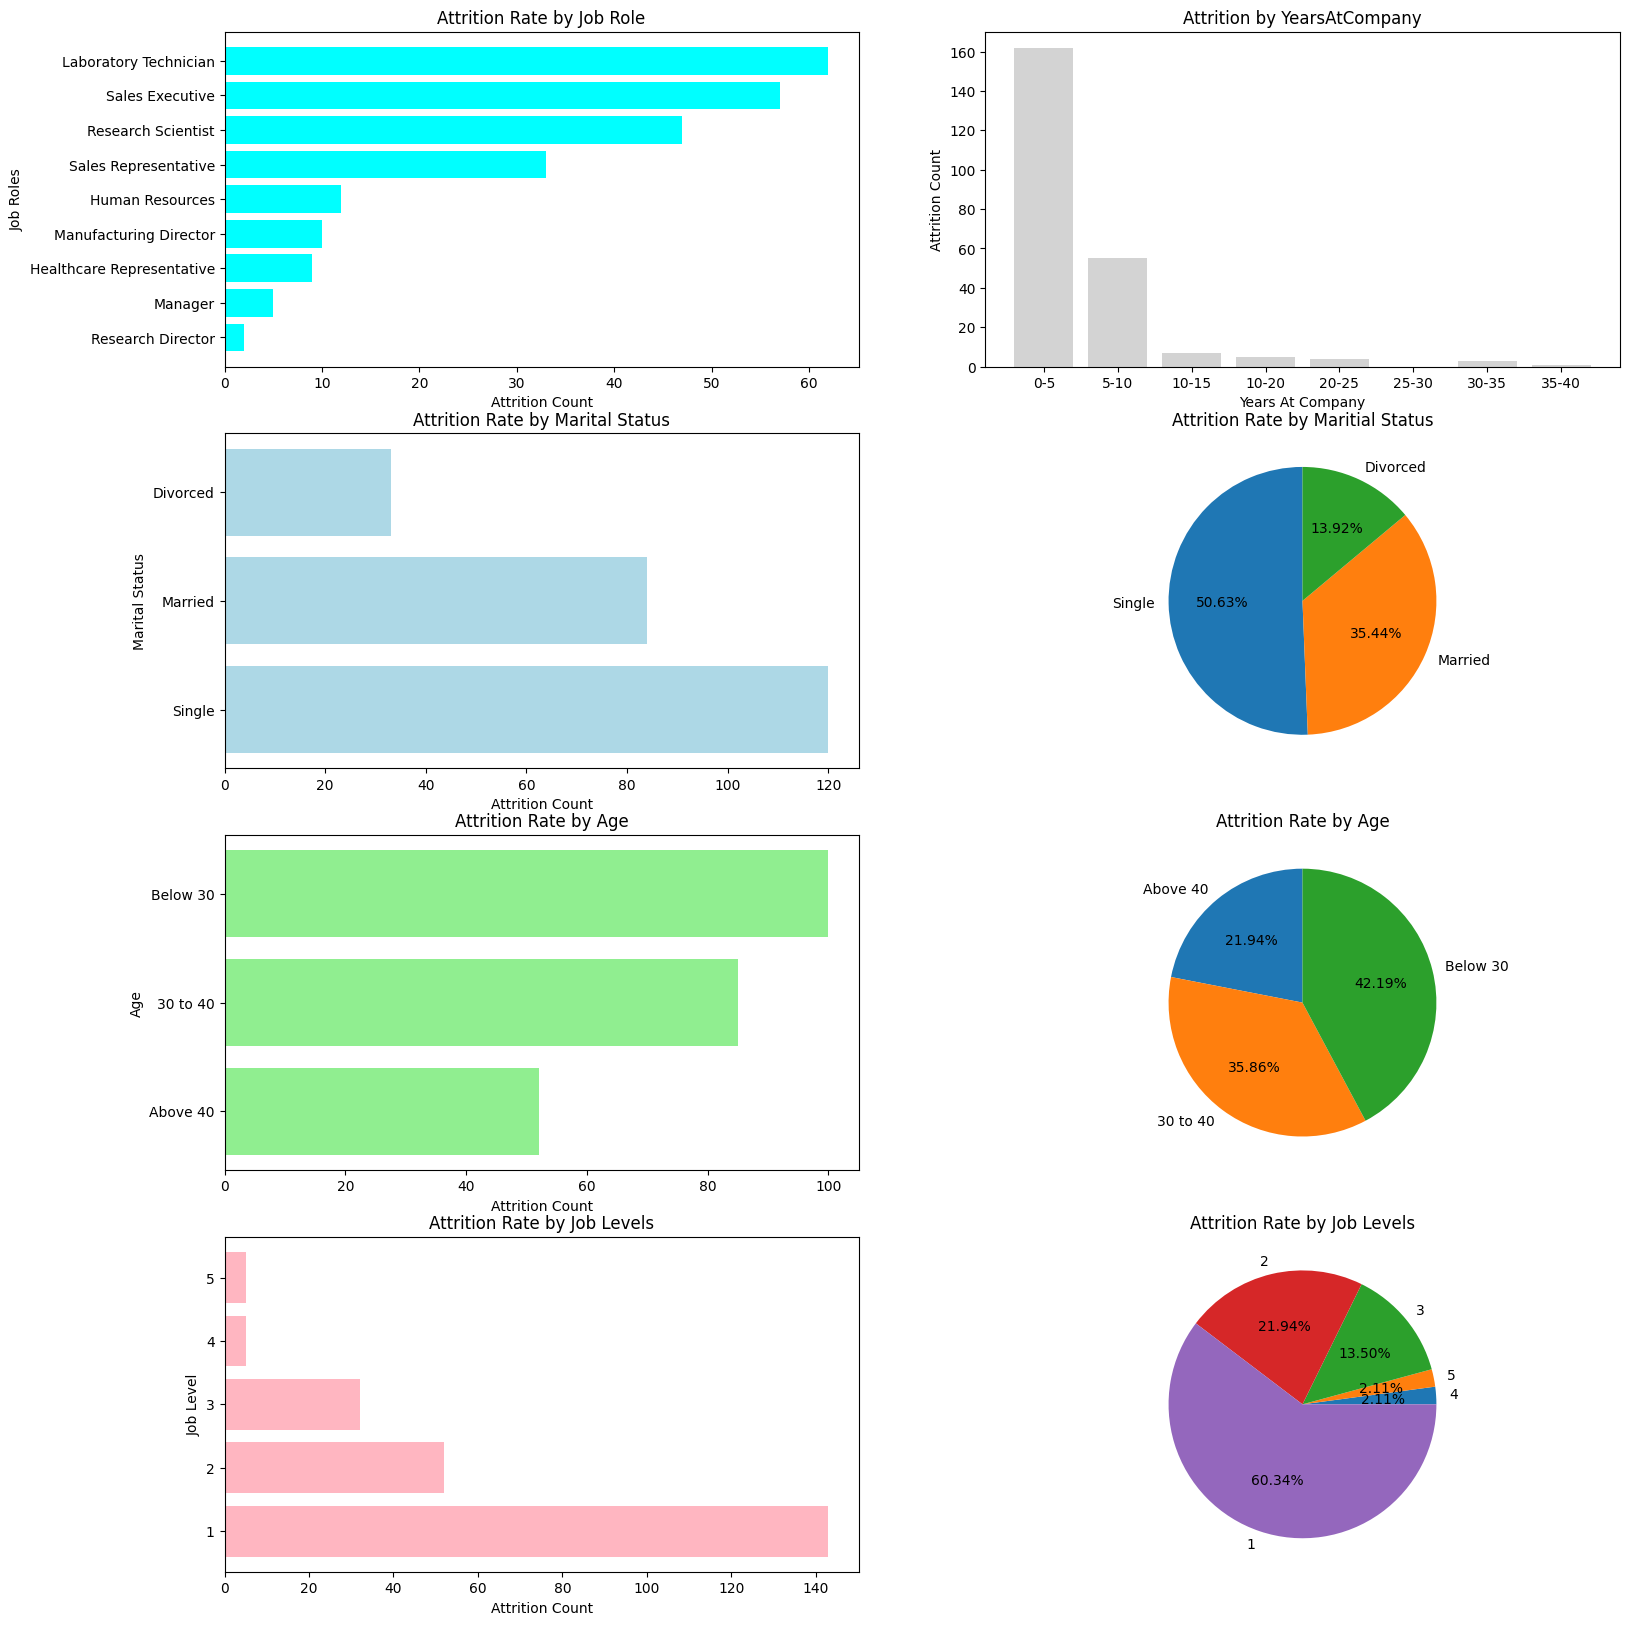

In [55]:
plt.figure(figsize=(18,20))

plt.subplot(4,2,1)
plt.barh(attrition_count_jobrole_sorted.index,attrition_count_jobrole_sorted.values,color='cyan')
plt.title("Attrition Rate by Job Role")
plt.ylabel('Job Roles')
plt.xlabel("Attrition Count")

plt.subplot(4,2,2)
plt.title("Attrition by YearsAtCompany")
plt.bar(attrition_count_YearsAtCompany_sorted.index,attrition_count_YearsAtCompany_sorted.values,color='lightgrey')
plt.xlabel('Years At Company')
plt.ylabel("Attrition Count")

#Marital Status
plt.subplot(4,2,3)
plt.title("Attrition Rate by Marital Status")
plt.barh(attrition_maritalstatus_yes.index,attrition_maritalstatus_yes.values,color='lightblue')
plt.xlabel("Attrition Count")
plt.ylabel('Marital Status')

plt.subplot(4,2,4)
plt.title("Attrition Rate by Maritial Status")
plt.pie(attrition_maritalstatus_yes.values,labels=attrition_maritalstatus_yes.index,
        autopct='%1.2f%%', 
        startangle=90)


#age
plt.subplot(4,2,5)
plt.title("Attrition Rate by Age")
plt.barh(attrition_age.index,attrition_age['Yes'],color='lightgreen')
plt.xlabel("Attrition Count")
plt.ylabel('Age')

plt.subplot(4,2,6)
plt.title("Attrition Rate by Age")
plt.pie(attrition_age['Yes'],labels=attrition_age.index,
        autopct='%1.2f%%', 
        startangle=90)


#job levels
plt.subplot(4,2,7)
plt.title("Attrition Rate by Job Levels")
plt.barh(attrition_count_JobLevel_sorted.index,attrition_count_JobLevel_sorted.values,color='lightpink')
plt.ylabel('Job Level')
plt.xlabel("Attrition Count")

plt.subplot(4,2,8)
plt.title("Attrition Rate by Job Levels")
plt.pie(attrition_count_JobLevel_sorted.values,
        labels=attrition_count_JobLevel_sorted.index,
        autopct='%1.2f%%',
        startangle=0)


plt.show()

## Conclusion & Recommendations

### HR Actionable Suggestions

1. Focus on High-Risk Roles: Prioritize retention strategies for Laboratory Technicians, Sales Executives, and Research Scientists.

2. Support Young Employees: Employees under 30 are leaving more—offer mentorship, career growth, and engagement programs.

3. Improve Compensation: Review salary structures; employees who left earned significantly less on average.

4. Engage Single Employees: Singles are more likely to leave—create inclusive social and support programs.

5. Monitor Promotions: Employees promoted recently tend to leave—ensure post-promotion support and recognition.

6. Address Job Satisfaction: Satisfaction levels 1 and 3 show higher attrition—conduct feedback sessions and improve role clarity.

7. Gender-Specific Retention: Male attrition is higher—explore gender-based engagement strategies.

8. Target Level 1 Employees: Provide growth paths and skill development for entry-level staff.

9. R&D & Sales Focus: These departments have highest attrition—tailor retention plans accordingly.

10. Income & Tenure Risk Zone: Employees earning ₹2000–₹8000 and with 0–10 years tenure need focused retention efforts.

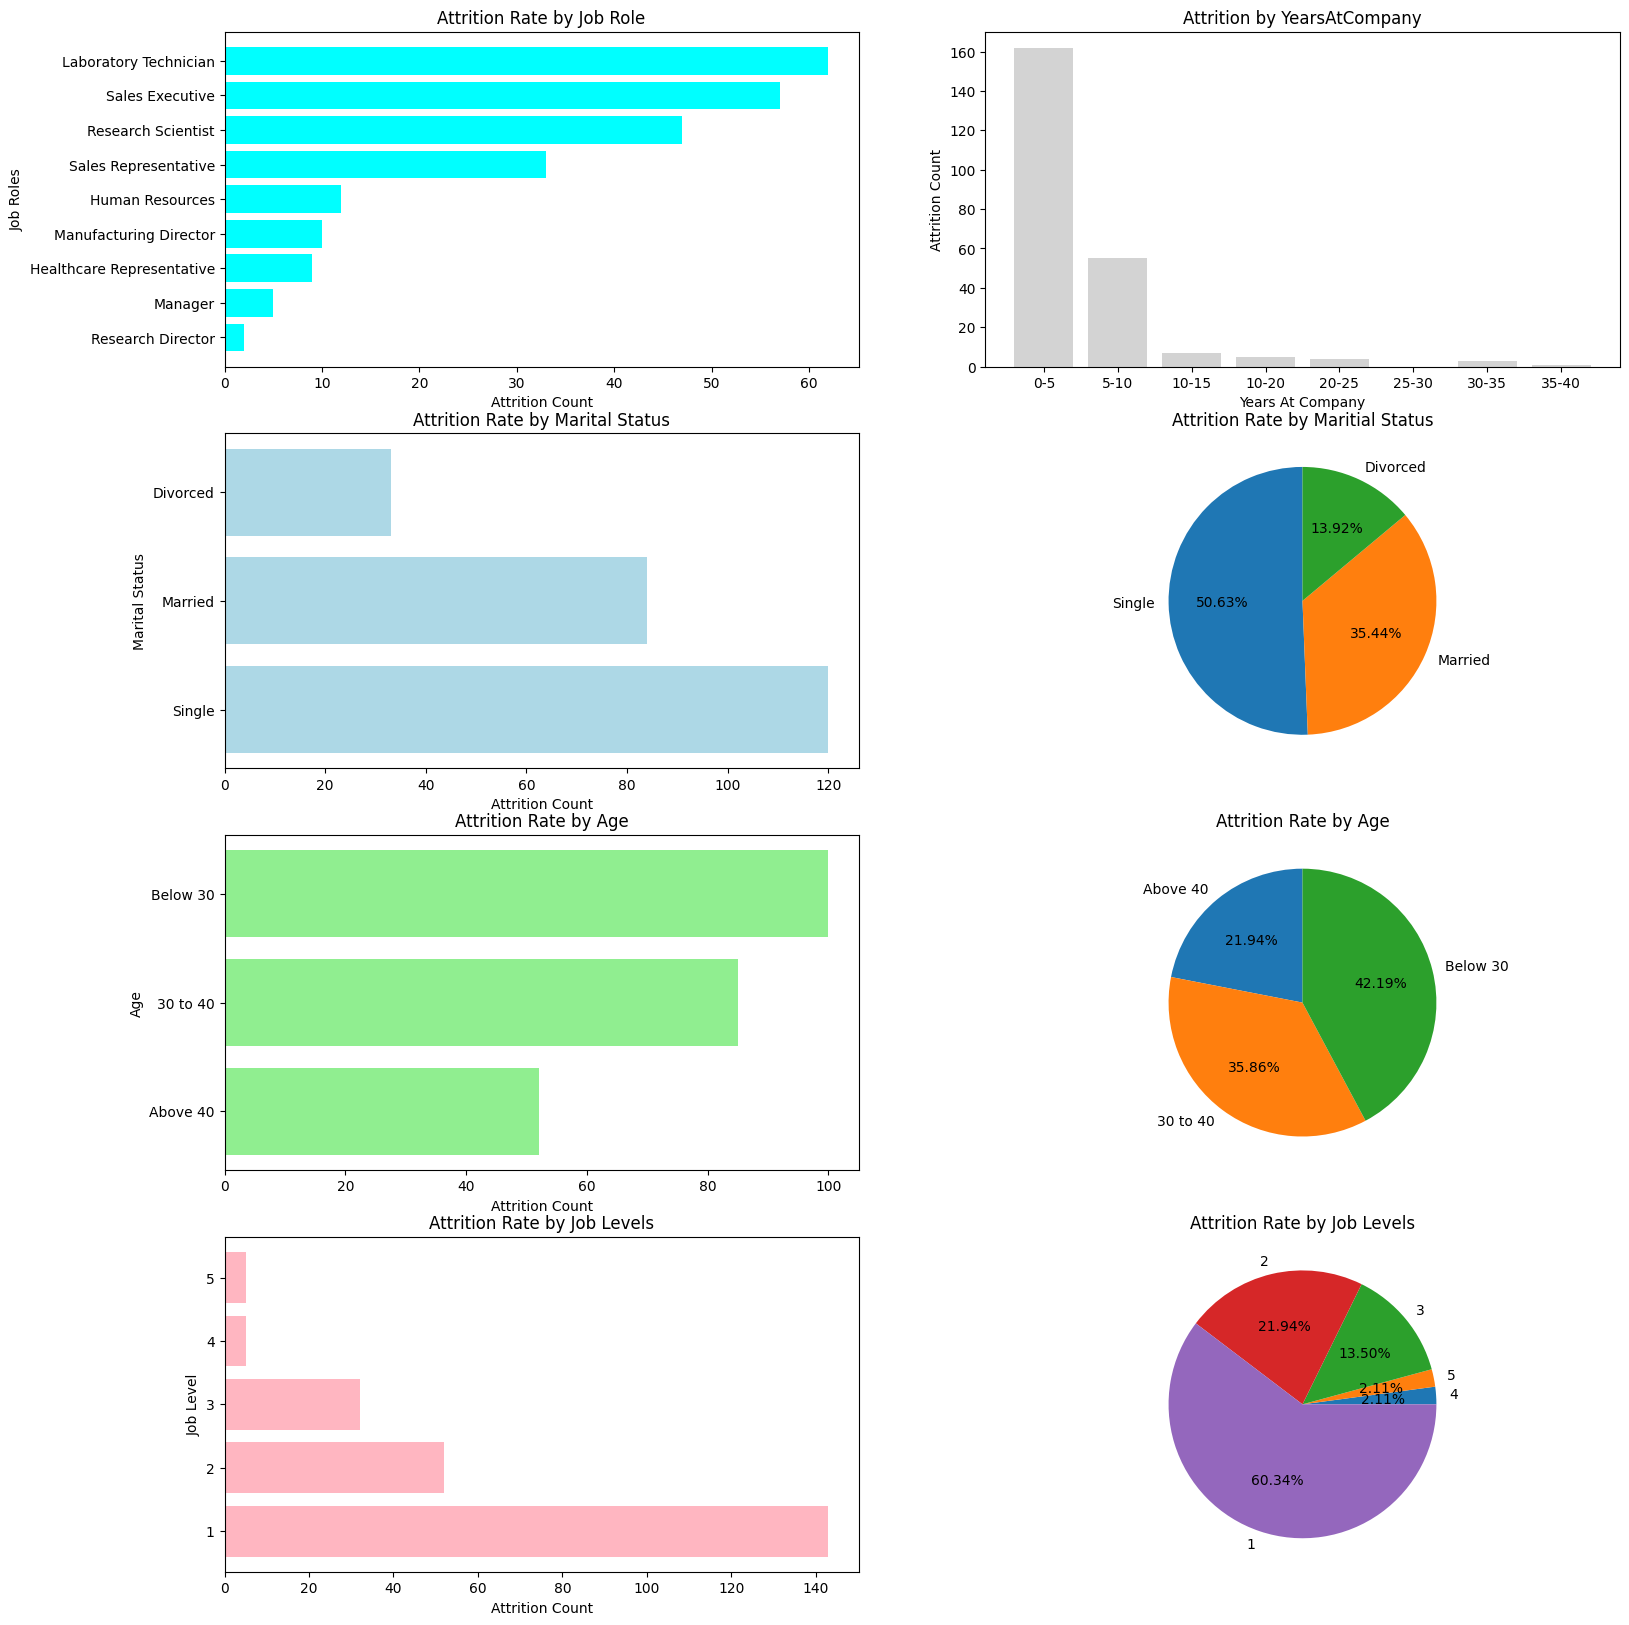
